In [ ]:
using ModelingToolkit
using ModelingToolkit: t_nounits as t, D_nounits as D
using OrdinaryDiffEq
using Plots
"""
Like RC circuit acausal model
https://docs.sciml.ai/ModelingToolkit/stable/tutorials/acausal_components/

Longer term: how to add additional ion flows?
Might have to properly understand: https://docs.sciml.ai/ModelingToolkit/stable/tutorials/domain_connections/#Multiple-Domain-Networks

Perhaps ion types can be extra units attached to dynamicquantities.

Liu ion channel? Listens to voltage AND calcium. So need to track calcium. 


connectors:
flow variable is current
across variable is voltage 
"""


@connector Pin begin
    v(t)
    i(t), [connect = Flow]
end

@mtkmodel Ground begin
    @parameters begin
        Ev = -70.0
    end
    @components begin
        g = Pin()
    end
    @equations begin
        g.v ~ Ev
    end
end

@mtkmodel OnePort begin
    @components begin
        p = Pin()
        n = Pin()
    end
    @variables begin
        v(t)
        i(t)
    end
    @equations begin
        v ~ p.v - n.v
        0 ~ p.i + n.i
        i ~ p.i
    end
end

"""
I = gleak*(V - Eleak )
"""


@component function LeakChannel(; v_in, name)
    pars = @parameters begin
        gleak = 0.002#0.003
        Eleak = -69.42#-49.42
    end

    vars = @variables begin
        i(t)#, [connect = Flow]
    end
    v = v_in
    eqs = [
        i ~ gleak * (v - Eleak)
    ]
    return ODESystem(eqs, t, vars, pars; name)
end





@component function SodiumChannel(;name, kwargs...)
    αₘ(x) = 0.1(35.0 + x) / (
        -exp(
            -(35.0 + x) / 10.0
        ) + 1.0
    )
    βₘ(x) = 4exp(
        -(x + 60) / 18.0
    )
    αₕ(x) = 0.07exp(-(x + 60.0) / 20.0)
    βₕ(x) = 1.0 / (
        1 + exp(
            (-30.0 - x) / 10.0
        )
    )
    pars = @parameters begin
        gNa = 1.2
        ENa = 55.17
    end
    vars = @variables begin
        m(t)=0
        h(t)=0
        i(t)#, [connect=Flow]
    end
        
    v = kwargs[:v_in]
    eqs = [
        D(m) ~ αₘ(v) * (1 - m) - βₘ(v) * m,
        D(h) ~ αₕ(v) * (1 - h) - βₕ(v) * h,
        i ~ gNa * m^3 * h * (ENa - v)
    ]
    return ODESystem(eqs, t, vars, pars; name)
end



@component function PotassiumChannel(; v_in, name)
    pars = @parameters begin
        gK = 0.36
        EK = -72.14
    end
    vars = @variables begin
        n(t) = 0.0
        i(t)#, [connect=Flow]
    end
    v = v_in
    αₙ(x) = 0.01(x + 50.0) / (1 - exp(
        -(50.0 + x) / 10.0
    )
    )
    βₙ(x) = 0.125exp(-(x + 60) / 80.0)
    τₙ(x) = 1.0 / (αₙ(x) + βₙ(x))
    eqs = [
        D(n) ~ αₙ(v) * (1 - n) - βₙ(v) * n,
        i ~ gK * n^4 * min(EK - v,0)
    ]
    return ODESystem(eqs, t, vars, pars; name)
end


@component function CalciumChannel(; v_in, name)
    pars = @parameters begin
        gCa = 0.1
        ECa = 120.0  # Very positive reversal potential
    end
    
    vars = @variables begin
        s(t) = 0.0  # Activation variable
        i(t)
        ca_conc(t) = 0.0  # Track intracellular calcium
    end
    
    v = v_in
    # Ca2+ activation dynamics
    αₛ(x) = 0.055(-27.0 - x)/(exp((-27.0 - x)/3.8) - 1)
    βₛ(x) = 0.94*exp((-75.0 - x)/17.0)
    
    # Ca2+ concentration dynamics (simplified)
    eqs = [
        D(s) ~ αₛ(v) * (1 - s) - βₛ(v) * s,
        i ~ gCa * s^2 * (ECa - v),
        D(ca_conc) ~ -0.13 * i - 0.075 * ca_conc  # Simple decay model
    ]
    
    return ODESystem(eqs, t, vars, pars; name)
end

@mtkmodel ActivationGate begin
    @extend OnePort()
    @variables Sodium(t)
end
"""
@component function Synapse(;name, presynaptic, postsynaptic, kwargs...)
    pars = @parameters begin
        gap_C = 0.01
        time_delay = 1.0
        pulse_width = 0.5
    end

    vars = @variables begin
        last_spike(t) = -100.0
        i(t)#, [connect=Flow]
    end

    eqs= [
        D(last_spike) ~ ifelse((presynaptic > 0) * (last_spike - (t - 5.0) < 0), 
                      t - last_spike, 0.0)

        i ~ ifelse(t > (last_spike + time_delay), 
         gap_C * (t - (last_spike + time_delay)) * exp(-(t - (last_spike + time_delay))/pulse_width),
         0.0)
    ]
    return ODESystem(eqs, t, vars, pars; name)
end
"""

@component function Synapse(;name, presynaptic, kwargs...)
    pars = @parameters begin
        gap_C = 100
        time_delay = 1.0
        pulse_width = 0.5
    end

    vars = @variables begin
        last_spike(t) = -100.0
        # Remove i(t) declaration completely
    end

    # No return value for current - we'll calculate it in Network
    eqs= [
        D(last_spike) ~ ifelse((presynaptic > 0) * (last_spike - (t - 5.0) < 0), 
                      t - last_spike, 0.0)
        # Remove the i equation completely
    ]
    return ODESystem(eqs, t, vars, pars; name)
end

@component function HHNeuron(;name, input_current=0.0, kwargs...)
    pars = @parameters begin
        C = 0.01
        gap_C = 0.02
        spike_threshold=-40.0
    end

    vars = @variables begin
        v(t) = -70
        spike_occurred(t) = 0.0
        i(t)#, [connect=Flow]
    end
    systems = @named begin
        so = SodiumChannel(; v_in = v)
        po = PotassiumChannel(; v_in = v)
        #ca = CalciumChannel(; v_in = v)
        l = LeakChannel(; v_in = v)
    end
    
    # Sum the currents from ion channels first
    channel_currents = sum(el.i for el in systems)
    # Then add the input current
    eqs = [
        C * D(v) ~ so.i+po.i+l.i + input_current
        spike_occurred ~ ifelse((v - spike_threshold > 0) * (D(v) > 0), 1.0, 0.0)    
    ]
    return ODESystem(eqs, t, vars, pars; systems, name)
end


@component function Network(;name)
    pars = @parameters begin
        gap_C = 0.02
    end
    @variables synaptic_current(t)
    @variables synaptic_current_1(t)
    @variables synaptic_current_2(t)

    @named neuron_post = HHNeuron(name=:neuron_post, input_current=synaptic_current)  # Post-synaptic records input
    @named neuron_pre_1 = HHNeuron(name=:neuron_pre_1, input_current=1.5)
    @named neuron_pre_2 = HHNeuron(name=:neuron_pre_2, input_current=1.0)
    @named synapse_1 = Synapse(name=:synapse_1, presynaptic=neuron_pre_1.spike_occurred)
    @named synapse_2 = Synapse(name=:synapse_2, presynaptic=neuron_pre_2.spike_occurred)
    systems = [neuron_pre_1, neuron_pre_2, neuron_post, synapse_1, synapse_2]

    # Gap junction current must be symmetric
    """eqs = [
        synaptic_current ~ synapse.i
    ]"""

    eqs = [
    # Calculate current directly here
    synaptic_current_1 ~ ifelse(t > (synapse_1.last_spike + synapse_1.time_delay), 
        synapse_1.gap_C * (t - (synapse_1.last_spike + synapse_1.time_delay)) * 
        exp(-(t - (synapse_1.last_spike + synapse_1.time_delay))/synapse_1.pulse_width),
        0.0)
    synaptic_current_2 ~ ifelse(t > (synapse_2.last_spike + synapse_2.time_delay), 
    synapse_2.gap_C * (t - (synapse_2.last_spike + synapse_2.time_delay)) * 
        exp(-(t - (synapse_2.last_spike + synapse_2.time_delay))/synapse_2.pulse_width),
        0.0)
    synaptic_current ~ synaptic_current_1 + synaptic_current_2
]



    return ODESystem(eqs, t, [synaptic_current], pars; systems, name)
end

coupled = Network(name=:coupled)
coupled = structural_simplify(coupled)
prob = ODEProblem(coupled, [], (0.0, 5))
sol = solve(prob, Tsit5())

┌ Warning: Initialization system is overdetermined. 3 equations for 0 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here. To suppress this warning pass warn_initialize_determined = false. To make this warning into an error, pass fully_determined = true
└ @ ModelingToolkit C:\Users\New laptop\.julia\packages\ModelingToolkit\K8zNC\src\systems\diffeqs\abstractodesystem.jl:1358


retcode: Success
Interpolation: specialized 4th order "free" interpolation
t: 29-element Vector{Float64}:
 0.0
 0.00797892903779763
 0.031788300405375114
 0.06965866299273994
 0.1192330238459769
 0.18490849435688045
 0.2657723383384354
 0.33554110872590626
 0.4021229290170683
 0.5537377710368775
 ⋮
 2.4015969108924873
 2.665851278324702
 2.962340966995656
 3.277644678793874
 3.640369675569665
 4.035860028274145
 4.4697760336303665
 4.791781585718211
 5.0
u: 29-element Vector{Vector{Float64}}:
 [-70.0, 0.0, 0.0, 0.0, -70.0, 0.0, 0.0, 0.0, -70.0, 0.0, 0.0, 0.0, -100.0, -100.0]
 [-68.80313148117483, 0.0008855860034175603, 0.0008933778652112425, 0.0002596200779565655, -69.20239641899731, 0.0008719584465947839, 0.0009022606881085851, 0.0002562274265687943, -70.00092629464223, 0.0008454208126106241, 0.0009203835175340897, 0.00024958879148455354, -100.0, -100.0]
 [-65.22026449897002, 0.0038031186700232607, 0.0032570170153043234, 0.0011622819022527426, -66.8147427256818, 0.0035529235198365422,

In [45]:
println(states(coupled))

UndefVarError: UndefVarError: `states` not defined

In [44]:
# After solving the system
t = sol.t
plot(t, [sol(t[i], idxs=coupled.synaptic_current_1)[1] for i in 1:length(t)], label="Synapse 1")
plot!(t, [sol(t[i], idxs=coupled.synaptic_current_2)[1] for i in 1:length(t)], label="Synapse 2")
plot!(t, [sol(t[i], idxs=coupled.synaptic_current)[1] for i in 1:length(t)], label="Combined")

ErrorException: cannot assign a value to imported variable Main.t

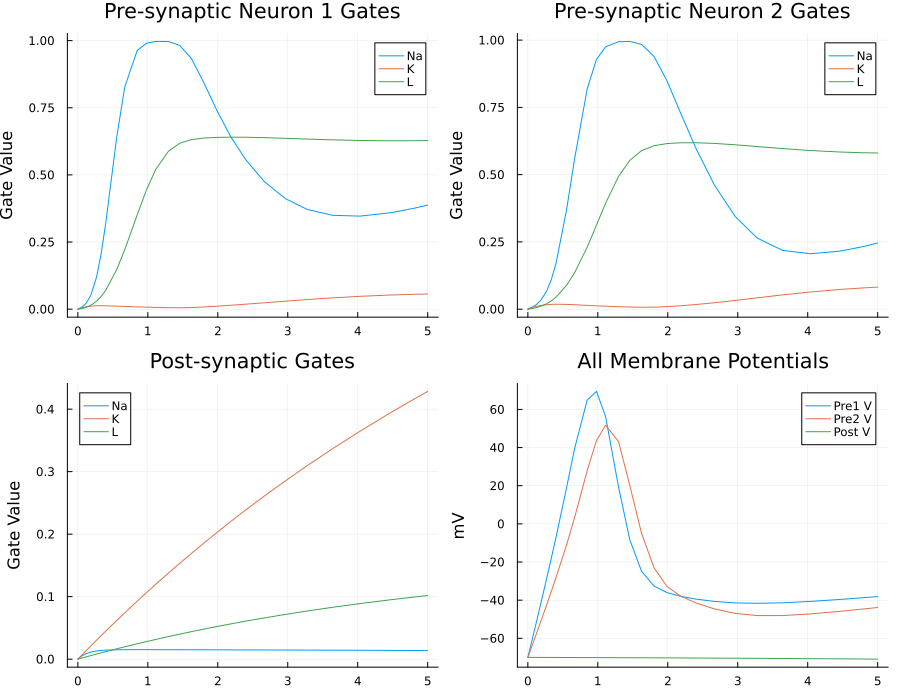

In [35]:
# Extract data
pre1_v = [state[1] for state in sol.u]
pre1_Na = [state[2] for state in sol.u]
pre1_K = [state[3] for state in sol.u]
pre1_L = [state[4] for state in sol.u]

pre2_v = [state[5] for state in sol.u]
pre2_Na = [state[6] for state in sol.u]
pre2_K = [state[7] for state in sol.u]
pre2_L = [state[8] for state in sol.u]

post_v = [state[9] for state in sol.u]
post_Na = [state[10] for state in sol.u]
post_K = [state[11] for state in sol.u]
post_L = [state[12] for state in sol.u]

# Four plots layout
p1 = plot(sol.t, [pre1_Na pre1_K pre1_L], 
     label=["Na" "K" "L"],
     title="Pre-synaptic Neuron 1 Gates",
     ylabel="Gate Value")

p2 = plot(sol.t, [pre2_Na pre2_K pre2_L], 
     label=["Na" "K" "L"],
     title="Pre-synaptic Neuron 2 Gates",
     ylabel="Gate Value")

p3 = plot(sol.t, [post_Na post_K post_L],
     label=["Na" "K" "L"],
     title="Post-synaptic Gates",
     ylabel="Gate Value")

p4 = plot(sol.t, [pre1_v pre2_v post_v],
     label=["Pre1 V" "Pre2 V" "Post V"],
     title="All Membrane Potentials",
     ylabel="mV")

# Arrange in a 2×2 grid
plot(p1, p2, p3, p4, layout=(2,2), size=(900, 700))

In [36]:
# Extract synapse data
syn1_last_spike = [state[13] for state in sol.u]
syn1_current = [state[14] for state in sol.u]  # Synaptic current
syn1_spike_occurred = diff([0; syn1_last_spike]) .> 0.1  # Detect changes in last_spike

syn2_last_spike = [state[15] for state in sol.u]
syn2_current = [state[16] for state in sol.u]
syn2_spike_occurred = diff([0; syn2_last_spike]) .> 0.1

# Create synapse plots
p_syn1 = plot(sol.t, syn1_current,
    label="Syn1 Current",
    title="Synapse 1 Activity",
    ylabel="Current")

p_syn2 = plot(sol.t, syn2_current,
    label="Syn2 Current", 
    title="Synapse 2 Activity",
    ylabel="Current")

# Add spike markers
for t_idx in findall(syn1_spike_occurred)
   vline!(p_syn1, [sol.t[t_idx]], label="", color=:red, alpha=0.5)
end

for t_idx in findall(syn2_spike_occurred)
   vline!(p_syn2, [sol.t[t_idx]], label="", color=:red, alpha=0.5)
end

# Plot both synapses
plot(p_syn1, p_syn2, layout=(2,1), size=(800, 400))

BoundsError: BoundsError: attempt to access 14-element Vector{Float64} at index [15]

In [ ]:
pre_v = [state[1] for state in sol.u]
pre_Na = [state[2] for state in sol.u]
pre_K = [state[3] for state in sol.u]
pre_L = [state[4] for state in sol.u]

# Post-synaptic neuron
post_v = [state[5] for state in sol.u]
post_Na = [state[6] for state in sol.u]
post_K = [state[7] for state in sol.u]
post_L = [state[8] for state in sol.u]

# Create a 2x2 subplot layout
p1 = plot(sol.t, [pre_Na pre_K pre_L], 
     label=["Na" "K" "L"],
     title="Pre-synaptic Gates",
     ylabel="Gate Value")

p2 = plot(sol.t, [post_Na post_K post_L],
     label=["Na" "K" "L"],
     title="Post-synaptic Gates",
     ylabel="Gate Value")

p3 = plot(sol.t, pre_v,
     label="Pre V",
     title="Membrane Potentials",
     ylabel="mV")

p4 = plot(sol.t, post_v,
     label="Post V",
     title="",
     ylabel="mV")

plot(p1, p2, p3, p4, layout=(2,2))

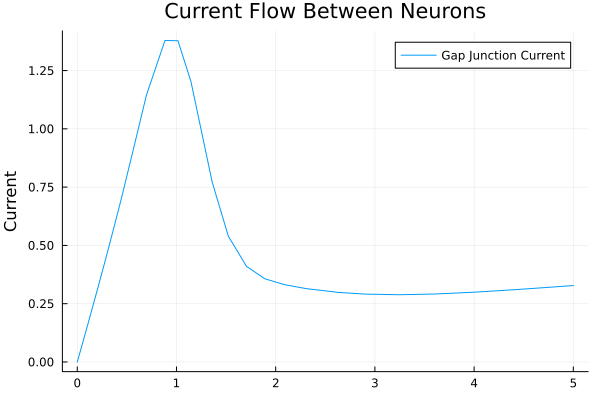

In [22]:
gap_current = [0.01 * (state[1] - state[5]) for state in sol.u]  # Using gap_C = 0.01
plot(sol.t, gap_current,
     label="Gap Junction Current",
     title="Current Flow Between Neurons",
     ylabel="Current")